In [2]:
import sklearn
from sklearn.cluster import AgglomerativeClustering, DBSCAN, KMeans
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import StandardScaler, OneHotEncoder



In [3]:
df_obras = pd.read_csv('../../db/clean/df_cluster.csv')


In [4]:
df_obras

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical
0,False,False,True,32324.0,1.0,1.0,218322.12,True,False,True,False,False,False,True,False,False
1,False,False,False,7958.0,5.0,5.0,76670.28,True,False,True,False,False,True,False,False,False
2,False,False,False,280.0,3.0,3.0,1476.00,True,False,True,False,False,True,False,False,False
3,False,False,True,47413.0,1.0,1.0,203675.61,True,False,True,False,False,False,True,False,False
4,False,False,True,8009.0,2.0,2.0,59887.00,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2243,True,False,True,14035.0,815.0,74.0,276329.35,True,False,True,False,False,True,False,False,False
2244,False,False,False,0.0,1.0,1.0,0.00,False,False,False,True,False,True,False,False,False
2245,False,False,False,735713.0,19090.0,140.0,15621834.49,False,False,True,False,False,False,True,False,False
2246,False,False,False,799.0,92.0,27.0,7925.15,True,False,True,False,False,True,False,False,False


In [ ]:
cols_numericas = ['publico_total', 'qtd_sessoes', 'dias_cartaz', 'renda_total']
cols_booleanas = ['investimento_fsa', 'coproducao', 'fomento_indireto',
                  'independente', 'curta_metragem', 'longa_metragem',
                  'media_metragem', 'animacao', 'documentario',
                  'ficcao', 'variedades', 'videomusical'
                  ]
scaler = StandardScaler()
df_obras[cols_numericas] = scaler.fit_transform(df_obras[cols_numericas])
obras = df_obras.copy()

In [6]:
obras.head()

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical
0,False,False,True,-0.102059,-0.272890,-0.489162,-0.130498,True,False,True,False,False,False,True,False,False
1,False,False,False,-0.141274,-0.271776,-0.441110,-0.148165,True,False,True,False,False,True,False,False,False
2,False,False,False,-0.153631,-0.272333,-0.465136,-0.157542,True,False,True,False,False,True,False,False,False
3,False,False,True,-0.077775,-0.272890,-0.489162,-0.132325,True,False,True,False,False,False,True,False,False
4,False,False,True,-0.141192,-0.272611,-0.477149,-0.150258,True,False,True,False,False,True,False,False,False


# Método do cotovelo

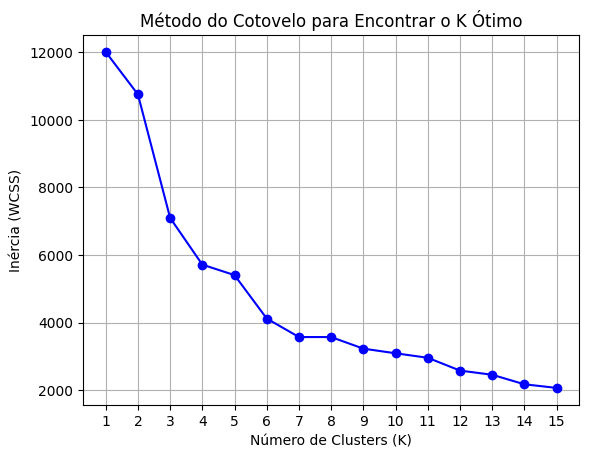

In [19]:
# Implementando o Método do Cotovelo com visualização iterativa
k_range = range(1, 16)
inertias = []
clustering_results = []

for k in k_range:
    model = KMeans(n_clusters=k, max_iter=150, random_state=42)
    model.fit(obras)

    inertias.append(model.inertia_)
    clustering_results.append({'labels': model.labels_, 'centroids': model.cluster_centers_})

# Plotar o gráfico do cotovelo
plt.plot(k_range, inertias, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia (WCSS)')
plt.title('Método do Cotovelo para Encontrar o K Ótimo')
plt.xticks(k_range)
plt.grid(True)
plt.show()

Text(0.5, 1.0, 'Visualização do agrupamento com k-means (Visualização PCA)')

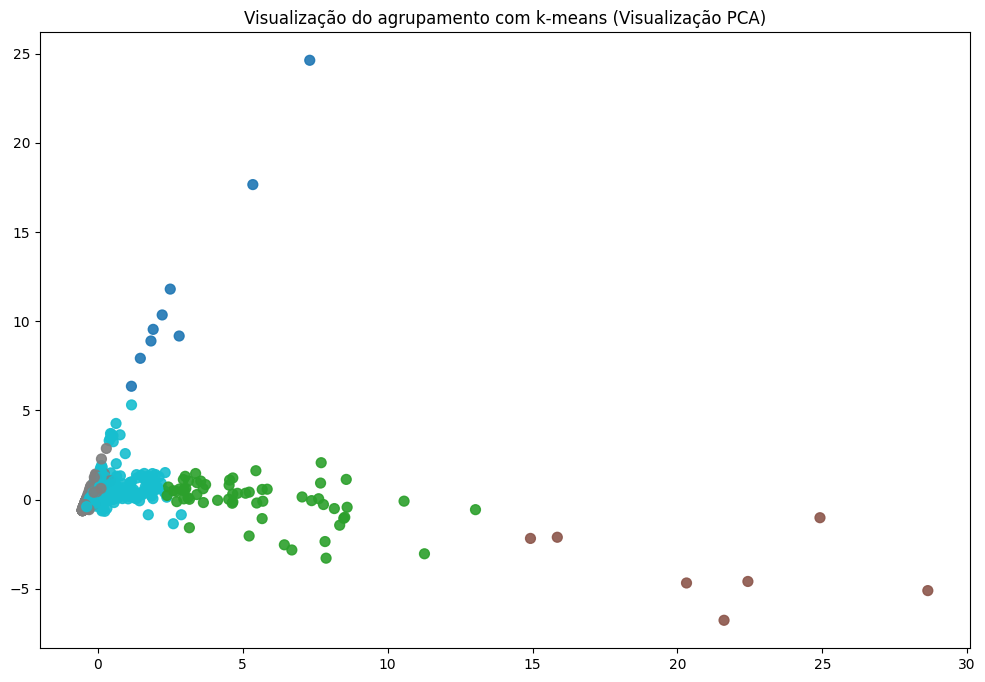

In [8]:
# k-means com PCA
kmeans = KMeans(n_clusters=5, random_state=0, n_init=10, init='k-means++').fit(obras)
labels = kmeans.labels_
clusters_kmeans = kmeans.predict(obras)
pca = PCA(n_components=8)
X_visualizacao = pca.fit_transform(obras)
# obras['cluster_kmeans'] = clusters_kmeans
plt.figure(figsize=(12, 8))
# sns.scatterplot(data=obras, x='publico_total', y= 'dias_cartaz', hue=clusters_kmeans, palette='tab10')
plt.scatter(X_visualizacao[:, 0], X_visualizacao[:, 1],
            c=labels,            # Define a cor de acordo com o grupo
            cmap='tab10',      # Paleta de cores
            s=50,                # Tamanho da bolinha
            alpha=0.9)           # Transparência (ajuda a ver sobreposição)

plt.title("Visualização do agrupamento com k-means (Visualização PCA)")

- tentamos com titulo original e deu erro
- tentamos com tipo de obra e nao encontramos semelhança
- com classificacao obra e nao encontramos similaridade entre pontos do mesmo cluster
- tentamos com duracao total em minutos e vemos que ele separou relativamente bem curtas e longa metragem

# Usando t-SNE para melhor visualização em duas dimensões

In [9]:
#reduz a dimensionalidade para observar melhor
tsne_obras = TSNE(n_components=2, init="random").fit_transform(obras)

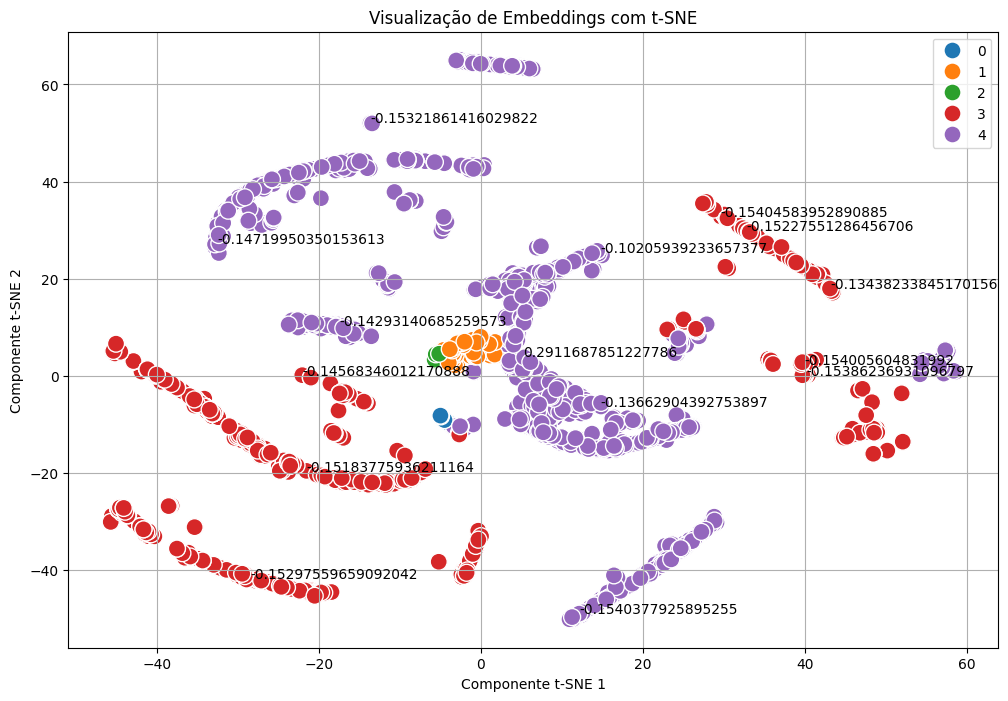

In [10]:
# Cria um DataFrame para a plotagem
df_tsne = pd.DataFrame({
    'x': tsne_obras[:, 0],
    'y': tsne_obras[:, 1],
    'titles': df_obras['publico_total'],
})

# Plota os resultados
plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_tsne, x='x', y='y', s=150, hue=clusters_kmeans, palette='tab10')

# Adiciona anotações aos pontos
for i in range(0, df_tsne.shape[0], 150):
    plt.text(
        df_tsne.x[i],
        df_tsne.y[i],
        df_tsne.titles[i],
        ha='left',
        size=10,
        color='black',
        alpha=1.0,
        weight='normal'
    )

plt.title('Visualização de Embeddings com t-SNE')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')
plt.grid(True)
plt.show()

# Utilizando PCA

In [11]:
pca_obras = PCA(n_components=2).fit_transform(obras)

Conseguimos observar uma aglomeração de alguns estilos como ficção e animação?

cremos que por ser uma base de dados com muito ruído o DBSCAN apresentaria melhor desempenho.

# Utilizando o DBSCAN

In [12]:
#padrão scikitlearn:(eps=0.5, *, min_samples=5, metric='euclidean', metric_params=None, algorithm='auto', leaf_size=30, p=None, n_jobs=None)
#através de testes arbitrários de 0.5 a 3.5
#1000000, 1386
dbscan = DBSCAN(eps=3, min_samples=2, metric='euclidean')
clusters_DBSCAN = dbscan.fit_predict(tsne_obras)

## podemos observar pelo texto indicando o publico total que o criterio de separação tem relação com o publico total.

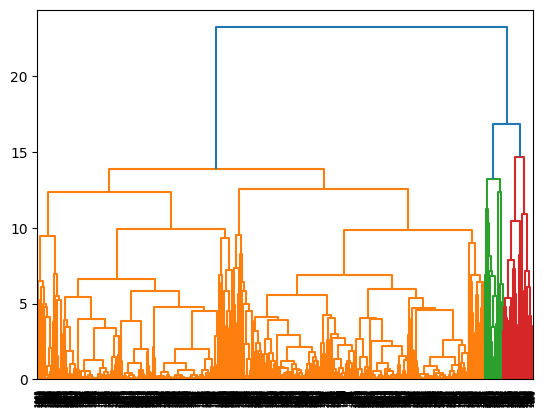

In [13]:
# obtendo medida de distância baseada no cosseno
similarity_distance = 1 - cosine_similarity(obras)

# computa a sequência de grupos unidos usando a ligação média
mergings = linkage(similarity_distance, method='average')

# configura o dendrograma
dendrogram_ = dendrogram(mergings,
               leaf_rotation=90
)

### sabemos que o melhor número de clusters é 5, pelo método do cotovelo aplicado acima

## observando os pontos nos centros de cada cluster

In [14]:
km = KMeans(n_clusters=6, random_state=0, n_init=10, init='k-means++')
km.fit(obras)
centers = km.cluster_centers_
centroids = pd.DataFrame(centers.round().astype(int))
centroids.columns = obras.keys().values
centroids.head()

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical
0,1,0,0,0,0,0,0,1,0,1,0,0,0,1,0,0
1,0,0,1,5,4,1,5,1,0,1,0,0,0,1,0,0
2,0,0,0,0,0,0,0,1,0,1,0,0,1,0,0,0
3,0,0,1,1,3,1,1,1,0,1,0,0,0,1,0,0
4,0,0,0,16,9,1,16,1,0,1,0,0,0,1,0,0


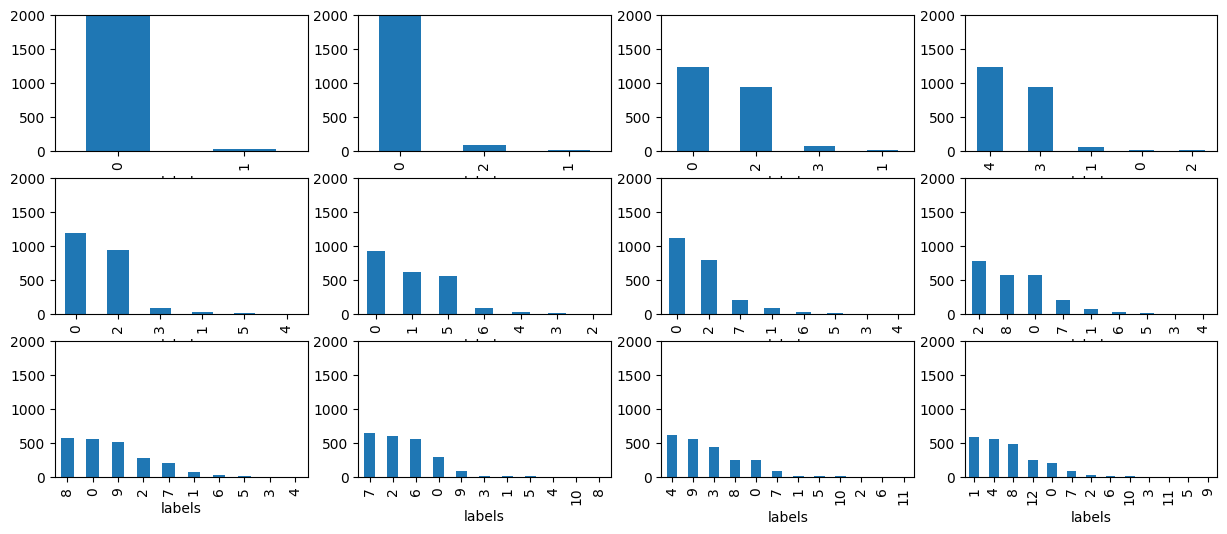

In [15]:
# configuração do gráfico que vai ser gerado
fig, axs = plt.subplots(3,4, figsize=(15, 6), facecolor='w', edgecolor='k')
axs = axs.ravel()

# dataframe para armazenar os dados
df = pd.DataFrame()

# intervalo com a quantidade de grupos que vamos dividir os dados
ks = range(2, 14)
for k in ks:
  km = KMeans(n_clusters=k, random_state=0, n_init=10, init='k-means++').fit(obras)
  labels = km.labels_.tolist()
  # cria um dataframe para facilitar a contagem dos objetos em cada grupo
  df['labels'] = labels
  # plota a quantidade de objetos em cada grupo
  df['labels'].value_counts().plot(kind='bar',ax=axs[k-2],ylim=(0,2000))

## Onservar os pontos no cluster 2

In [16]:
obras[km.labels_ == 2]

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical
286,False,False,True,3.447368,2.918468,0.808259,2.938653,True,False,True,False,False,False,True,False,False
303,False,False,True,2.891423,2.283649,0.760206,2.662614,True,False,True,False,False,False,True,False,False
305,True,False,True,2.731936,2.455719,1.084562,2.554944,True,False,True,False,False,False,True,False,False
318,False,False,True,2.705123,2.178681,1.685220,2.427924,True,False,True,False,False,False,True,False,False
380,False,False,True,3.929946,5.902675,1.805351,3.237166,True,False,True,False,False,False,True,False,False
414,True,False,True,1.372491,3.561640,0.916377,1.362127,True,False,True,False,False,False,True,False,False
420,False,False,True,4.094598,3.832830,1.432943,3.950591,True,False,True,False,False,False,True,False,False
460,True,False,True,2.482534,3.034573,0.375785,2.476135,True,False,True,False,False,False,True,False,False
522,False,False,True,3.910182,5.927733,0.892351,3.407977,True,False,True,False,False,False,True,False,False
688,False,False,True,2.617396,4.886964,0.363772,2.491330,True,False,True,False,False,False,True,False,False


### para fins de exemplo vamos mostrar como seria com mais grupos

In [ ]:
ks = range(6, 15)
for k in ks:
km = KMeans(n_clusters=5, random_state=0, n_init=10, init='k-means++')
km.fit(obras)
centers = km.cluster_centers_
df_centros = pd.DataFrame(centers, columns=df_obras.columns)
df_centros[cols_numericas] = scaler.inverse_transform(df_centros[cols_numericas])
df_centros['cluster'] = range(len(df_centros))
df_centros.round().astype(int)

0    1186
2     934
3      91
1      23
5       9
4       5
Name: count, dtype: int64


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,1,0,0,19772,506,39,257536,1,0,1,0,0,0,1,0,0,0
1,0,0,1,3442884,16581,105,44084342,1,0,1,0,0,0,1,0,0,1
2,0,0,0,2549,101,28,35188,1,0,1,0,0,1,0,0,0,2
3,0,0,1,663005,10009,92,9165877,1,0,1,0,0,0,1,0,0,3
4,0,0,0,9902008,33309,158,130003803,1,0,1,0,0,0,1,0,0,4
5,0,0,1,40039,5746,1073,742348,1,0,1,0,0,0,1,0,0,5


0    929
1    624
5    565
6     92
4     24
3      9
2      5
Name: count, dtype: int64


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,0,0,0,2553,100,28,35174,1,0,1,0,0,1,0,0,0,0
1,1,0,1,23650,601,42,309967,1,0,1,0,0,0,1,0,0,1
2,0,0,0,9902008,33309,158,130003803,1,0,1,0,0,0,1,0,0,2
3,0,0,1,40039,5746,1073,742348,1,0,1,0,0,0,1,0,0,3
4,0,0,1,3392671,16368,105,43281980,1,0,1,0,0,0,1,0,0,4
5,0,0,0,14647,391,35,186806,1,0,1,0,0,0,1,0,0,5
6,0,0,1,636112,9840,97,8868783,1,0,1,0,0,0,1,0,0,6


0    1123
2     789
7     207
1      91
6      23
5       8
3       5
4       2
Name: count, dtype: int64


...

,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,1,0,0,2710,169,33,37724,1,0,1,0,0,0,1,0,0,0
1,0,0,1,2554470,24408,125,37973150,1,0,1,0,0,0,1,0,0,1
2,0,0,0,10913184,23210,151,132950717,0,0,1,0,0,0,1,0,0,2
3,0,0,0,6470,176,26,84542,1,0,1,0,0,0,1,0,0,3
4,0,0,0,2788,95,28,35568,1,0,1,0,0,1,0,0,0,4
5,0,0,0,22669,1821,599,405873,1,0,1,0,0,0,1,0,0,5
6,1,0,1,90518,15680,1872,1605126,1,0,1,0,0,0,1,0,0,6
7,1,0,1,649772,9307,90,8889420,1,0,1,0,0,0,1,0,0,7
8,1,0,0,2357,148,31,35630,1,0,1,0,0,1,0,0,0,8
9,1,0,1,32782,854,45,434021,1,0,1,0,0,0,1,0,0,9


1     592
4     559
8     489
12    248
0     205
7      90
2      27
6      16
10     11
3       4
11      4
5       2
9       1
Name: count, dtype: int64


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,0,0,0,699,52,22,12296,1,0,0,1,0,0,0,0,0,0
1,1,0,1,18004,547,40,242492,1,0,1,0,0,0,1,0,0,1
2,0,0,1,1570584,17943,122,21877902,1,0,1,0,0,0,1,0,0,2
3,0,0,0,10913184,23210,151,132950717,0,0,1,0,0,0,1,0,0,3
4,0,0,0,3122,100,28,41434,1,0,1,0,0,1,0,0,0,4
5,1,0,1,90518,15680,1872,1605126,1,0,1,0,0,0,1,0,0,5
6,0,0,0,24166,1742,581,408554,1,0,1,0,0,0,1,0,0,6
7,1,0,1,475505,7535,85,6478280,1,0,1,0,0,0,1,0,0,7
8,0,0,0,13303,365,34,165223,1,0,1,0,0,0,1,0,0,8
9,0,1,0,5857306,73704,185,118216149,1,0,1,0,0,0,1,0,0,9


2     537
0     436
6     354
11    302
8     265
5     206
9      95
7      25
1       9
10      8
12      4
4       4
3       2
13      1
Name: count, dtype: int64


,investimento_fsa,coproducao,fomento_indireto,publico_total,qtd_sessoes,dias_cartaz,renda_total,independente,curta_metragem,longa_metragem,media_metragem,animacao,documentario,ficcao,variedades,videomusical,cluster
0,1,0,1,3417,124,31,45558,1,0,1,0,0,1,0,0,0,0
1,0,0,1,4230575,3760,62,44500339,1,0,1,0,0,0,1,0,0,1
2,1,0,1,26079,739,44,342455,1,0,1,0,0,0,1,0,0,2
3,1,0,1,90518,15680,1872,1605126,1,0,1,0,0,0,1,0,0,3
4,0,0,1,3891563,35777,91,66447438,1,0,1,0,0,0,1,0,0,4
5,0,0,0,758,56,25,13495,1,0,0,1,0,0,0,0,0,5
6,0,0,0,2217,92,26,31720,1,0,1,0,0,1,0,0,0,6
7,0,0,1,1857894,18194,125,25308795,1,0,1,0,0,0,1,0,0,7
8,1,0,0,2881,193,37,40968,1,0,1,0,0,0,1,0,0,8
9,1,0,1,477202,7775,92,6569164,1,0,1,0,0,0,1,0,0,9


In [18]:
# Crie um DataFrame de médias para a descrição
# cluster_medians = obras.groupby('cluster_kmeans').median()

# Exiba as médias para identificar as características únicas de cada cluster (Cluster 0, Cluster 1, etc.)
# display(cluster_medians)